In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [2]:
# Dataset Load
df = pd.read_csv("../data/processed/02_nav_history_clean.csv")
df = pd.read_csv("../data/processed/nav_history_daily_returns.csv")

In [3]:
# Converted date to datetime
df["date"] = pd.to_datetime(df["date"])

In [4]:
# Sorted by amfi_code and date
df = df.sort_values(["amfi_code", "date"])

In [5]:
# Calculated daily_return using pct_change()
df["daily_return"] = (
    df.groupby("amfi_code")["nav"]
      .pct_change()
)

In [6]:
# Removed first-row NaN values
df = df.dropna(subset=["daily_return"])

In [7]:
print(df.head())

   amfi_code       date       nav  daily_return
1     100016 2022-01-07  515.1639     -0.001210
2     100016 2022-01-10  510.7136     -0.008639
3     100016 2022-01-11  513.5542      0.005562
4     100016 2022-01-12  512.3195     -0.002404
5     100016 2022-01-13  510.2445     -0.004050


In [8]:
# Checked describe() output
print(df["daily_return"].describe())

count    45840.000000
mean         0.000632
std          0.010291
min         -0.058102
25%         -0.005039
50%          0.000341
75%          0.006325
max          0.064713
Name: daily_return, dtype: float64


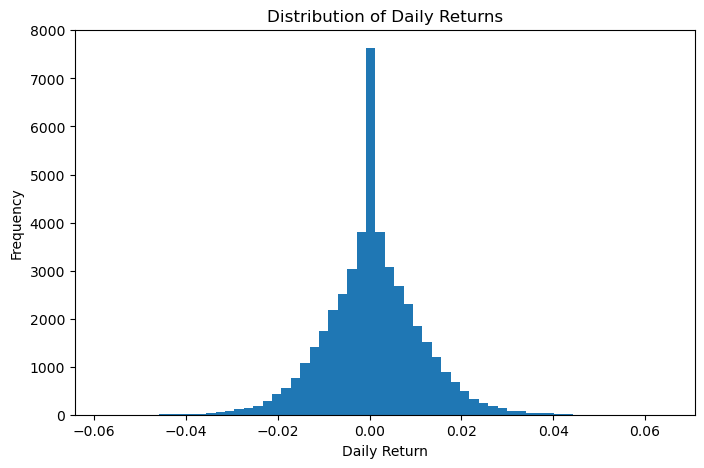

In [9]:
#Validated the distribution (mean, std, min, max look reasonable)
plt.figure(figsize=(8,5))

plt.hist(
    df["daily_return"],
    bins=60
)

plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Returns")

plt.savefig("../reports/15_daily_return_distribution.png")

plt.show()

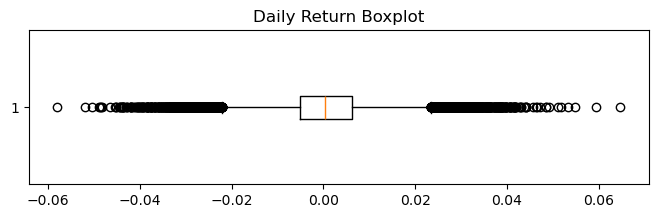

In [10]:
# Created and saved boxplot
plt.figure(figsize=(8,2))

plt.boxplot(df["daily_return"], vert=False)

plt.title("Daily Return Boxplot")

plt.savefig("../reports/16_daily_return_boxplot.png")

plt.show()

In [11]:
print(df["daily_return"].min())
print(df["daily_return"].max())

-0.058102013949189124
0.06471309359097144


In [12]:
print(df["daily_return"].isnull().sum())

0


In [13]:
# Saved nav_history_daily_returns.csv
df.to_csv(
    "../data/processed/nav_history_daily_returns.csv",
    index=False
)

print("Daily returns saved successfully!")

Daily returns saved successfully!


In [14]:
## Key Insight

# The daily returns are centered close to 0%, with most values lying in a small range and only a few outliers. This indicates a stable and reasonable return distribution across the mutual fund schemes.

In [15]:
## Task 2

In [16]:
# Short data
df = df.sort_values(["amfi_code", "date"])

In [17]:
# Function to Calculate CAGR
def calculate_cagr(group, years):
    latest = group.iloc[-1]

    target_date = latest["date"] - pd.DateOffset(years=years)

    previous = group[group["date"] <= target_date]

    if previous.empty:
        return np.nan

    start_nav = previous.iloc[-1]["nav"]
    end_nav = latest["nav"]

    return (end_nav / start_nav) ** (1 / years) - 1

In [18]:
# Calculate CAGR
results = []

for amfi_code, group in df.groupby("amfi_code"):

    results.append({
        "amfi_code": amfi_code,
        "CAGR_1Y": calculate_cagr(group,1),
        "CAGR_3Y": calculate_cagr(group,3),
        "CAGR_5Y": calculate_cagr(group,5)
    })

cagr_df = pd.DataFrame(results)

In [19]:
# Percentage Format
cagr_df["CAGR_1Y"] = cagr_df["CAGR_1Y"] * 100
cagr_df["CAGR_3Y"] = cagr_df["CAGR_3Y"] * 100
cagr_df["CAGR_5Y"] = cagr_df["CAGR_5Y"] * 100

In [20]:
# View Table
print(cagr_df.head())

   amfi_code    CAGR_1Y    CAGR_3Y  CAGR_5Y
0     100016  -2.224271   1.292649      NaN
1     100025   3.704969   3.916390      NaN
2     100033  53.232396  32.442459      NaN
3     101206  47.924120  28.967695      NaN
4     101207 -23.986032  -4.152381      NaN


In [21]:
# Save Table
cagr_df.to_csv(
    "../data/processed/cagr_comparison_table.csv",
    index=False
)

print("CAGR comparison table saved successfully!")

CAGR comparison table saved successfully!


In [22]:
# Markdown Insight

#The CAGR comparison table summarizes the annualized returns for all 40 mutual fund schemes over 1-year, 3-year, and 5-year periods. It enables consistent comparison of long-term performance across funds while reducing the effect of short-term market fluctuations.

In [23]:
# Task 3


In [24]:
# Risk Free Rate
annual_rf = 0.065

daily_rf = annual_rf / 252

In [25]:
# Calculate Sharpe Ratio
results = []

for amfi_code, group in df.groupby("amfi_code"):

    mean_return = group["daily_return"].mean()

    std_return = group["daily_return"].std()

    sharpe = ((mean_return - daily_rf) / std_return) * np.sqrt(252)

    results.append({
        "amfi_code": amfi_code,
        "Mean_Daily_Return": mean_return,
        "Std_Dev": std_return,
        "Sharpe_Ratio": sharpe
    })

sharpe_df = pd.DataFrame(results)

In [26]:
# Rank Funds
sharpe_df = sharpe_df.sort_values(
    by="Sharpe_Ratio",
    ascending=False
)

sharpe_df["Rank"] = range(1, len(sharpe_df)+1)

In [27]:
# View Result
print(sharpe_df.head(10))

    amfi_code  Mean_Daily_Return   Std_Dev  Sharpe_Ratio  Rank
34     148567           0.001053  0.008930      1.412853     1
30     120843           0.001072  0.009998      1.292626     2
36     148569           0.001106  0.011138      1.208098     3
19     119551           0.000902  0.008657      1.181174     4
25     120505           0.001160  0.012120      1.180873     5
38     149323           0.001062  0.011183      1.141504     6
2      100033           0.001103  0.011934      1.123514     7
9      118632           0.000860  0.008923      1.070917     8
3      101206           0.000851  0.009188      1.025459     9
24     120504           0.000840  0.009044      1.021147    10


In [28]:
# Save CSV
sharpe_df.to_csv(
    "../data/processed/sharpe_ratio_ranking.csv",
    index=False
)

print("Sharpe Ratio ranking saved successfully!")

Sharpe Ratio ranking saved successfully!


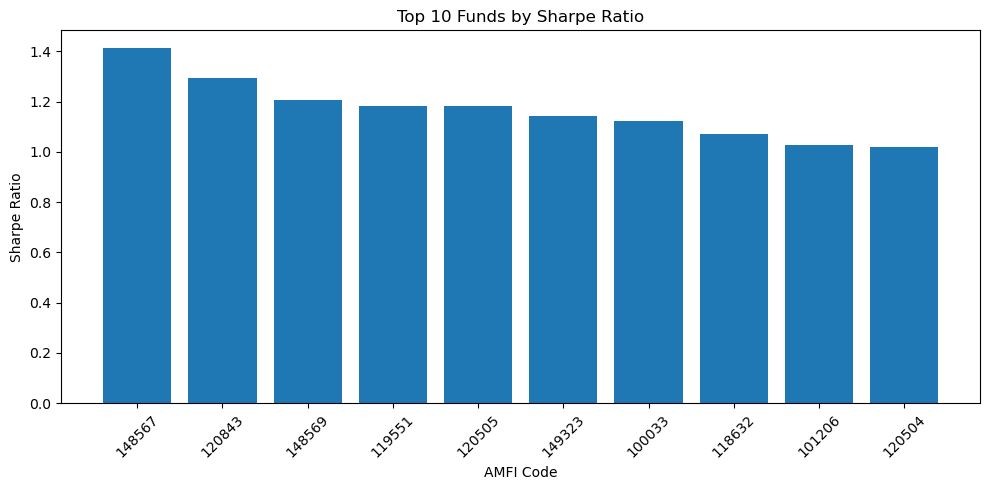

In [29]:
# Bar Chart
import matplotlib.pyplot as plt

top10 = sharpe_df.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["Sharpe_Ratio"]
)

plt.xticks(rotation=45)

plt.xlabel("AMFI Code")
plt.ylabel("Sharpe Ratio")
plt.title("Top 10 Funds by Sharpe Ratio")

plt.tight_layout()

plt.savefig("../reports/17_sharpe_ratio_top10.png")

plt.show()

In [30]:
## Insight

# The Sharpe Ratio ranks funds based on their risk-adjusted returns. Higher Sharpe Ratios indicate better returns for each unit of risk taken. The ranking highlights the best-performing mutual funds after accounting for volatility.

In [31]:
# task 4

In [32]:
# Calculate Sortino Ratio
results = []

for amfi_code, group in df.groupby("amfi_code"):

    mean_return = group["daily_return"].mean()

    downside_returns = group[group["daily_return"] < 0]["daily_return"]

    downside_std = downside_returns.std()

    if pd.isna(downside_std) or downside_std == 0:
        sortino = np.nan
    else:
        sortino = ((mean_return - daily_rf) / downside_std) * np.sqrt(252)

    results.append({
        "amfi_code": amfi_code,
        "Mean_Daily_Return": mean_return,
        "Downside_Std": downside_std,
        "Sortino_Ratio": sortino
    })

sortino_df = pd.DataFrame(results)

In [33]:
# Rank Funds
sortino_df = sortino_df.sort_values(
    by="Sortino_Ratio",
    ascending=False
)

sortino_df["Rank"] = range(1, len(sortino_df)+1)

In [34]:
# View Results
print(sortino_df.head(10))

    amfi_code  Mean_Daily_Return  Downside_Std  Sortino_Ratio  Rank
30     120843           0.001072      0.005533       2.335946     1
34     148567           0.001053      0.005432       2.322644     2
36     148569           0.001106      0.006404       2.101141     3
19     119551           0.000902      0.004885       2.093524     4
25     120505           0.001160      0.007062       2.026620     5
38     149323           0.001062      0.006752       1.890521     6
2      100033           0.001103      0.007146       1.876483     7
9      118632           0.000860      0.005209       1.834456     8
3      101206           0.000851      0.005239       1.798418     9
24     120504           0.000840      0.005146       1.794510    10


In [35]:
# Save CSV
sortino_df.to_csv(
    "../data/processed/sortino_ratio_ranking.csv",
    index=False
)

print("Sortino Ratio ranking saved successfully!")

Sortino Ratio ranking saved successfully!


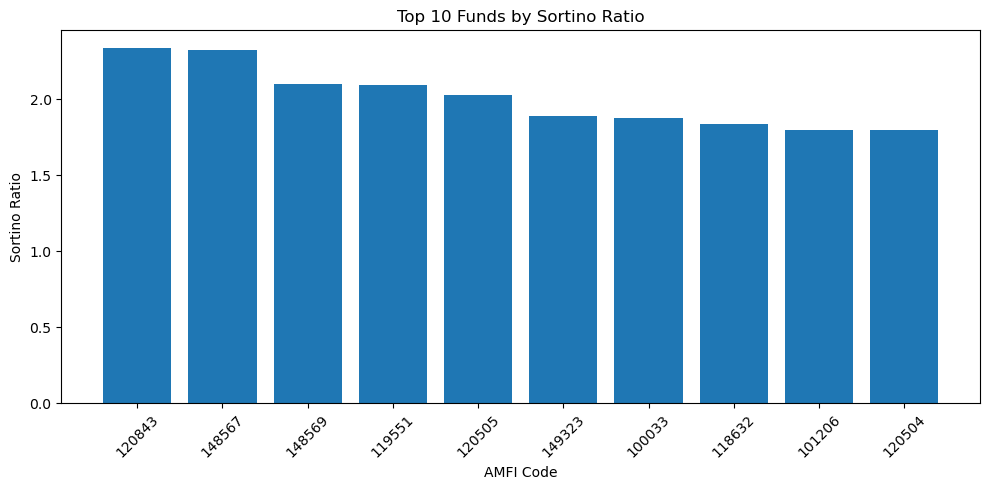

In [36]:
# Top 10 Bar Chart
top10 = sortino_df.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["Sortino_Ratio"]
)

plt.xticks(rotation=45)
plt.xlabel("AMFI Code")
plt.ylabel("Sortino Ratio")
plt.title("Top 10 Funds by Sortino Ratio")

plt.tight_layout()

plt.savefig("../reports/18_sortino_ratio_top10.png")

plt.show()

In [37]:
## Insight

# The Sortino Ratio evaluates risk-adjusted performance by considering only downside volatility. Funds with higher Sortino Ratios generated better returns while experiencing lower downside risk, making them more attractive for risk-conscious investors.

In [38]:
#task-5

In [39]:
fund = pd.read_csv("../data/processed/nav_history_daily_returns.csv")

In [40]:
nifty = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [41]:
# Keep only NIFTY100 data
nifty = nifty[nifty["index_name"] == "NIFTY100"].copy()

# Convert date
nifty["date"] = pd.to_datetime(nifty["date"])

# Sort by date
nifty = nifty.sort_values("date")

# Calculate daily market returns
nifty["market_return"] = nifty["close_value"].pct_change()

# Remove first NaN row
nifty = nifty.dropna(subset=["market_return"])

In [42]:
print(nifty.head())

           date index_name  close_value  market_return
1151 2022-01-04   NIFTY100     17537.52      -0.013540
1152 2022-01-05   NIFTY100     17607.73       0.004003
1153 2022-01-06   NIFTY100     17556.05      -0.002935
1154 2022-01-07   NIFTY100     17664.02       0.006150
1155 2022-01-10   NIFTY100     17516.51      -0.008351


In [43]:
# Prepare Fund Data
fund["date"] = pd.to_datetime(fund["date"])

In [44]:
# Merge Dataset
merged = fund.merge(
    nifty[["date", "market_return"]],
    on="date",
    how="inner"
)

In [45]:
# Calculate Alpha & Beta
results = []

for amfi_code, group in merged.groupby("amfi_code"):

    regression = linregress(
        group["market_return"],
        group["daily_return"]
    )

    beta = regression.slope

    alpha = regression.intercept * 252

    results.append({
        "amfi_code": amfi_code,
        "Alpha": alpha,
        "Beta": beta,
        "R_squared": regression.rvalue ** 2,
        "P_value": regression.pvalue
    })

alpha_beta_df = pd.DataFrame(results)

In [46]:
# Rank by Alpha
alpha_beta_df = alpha_beta_df.sort_values(
    by="Alpha",
    ascending=False
)

print(alpha_beta_df.head())

    amfi_code     Alpha      Beta  R_squared   P_value
21     119598  0.307625 -0.025675   0.000173  0.656500
39     149324  0.306133  0.009174   0.000023  0.872241
25     120505  0.292370 -0.005009   0.000011  0.909661
36     148569  0.277978  0.018762   0.000187  0.643747
2      100033  0.277769  0.002534   0.000003  0.953520


In [47]:
# Save CSV
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("Alpha Beta analysis saved successfully!")

Alpha Beta analysis saved successfully!


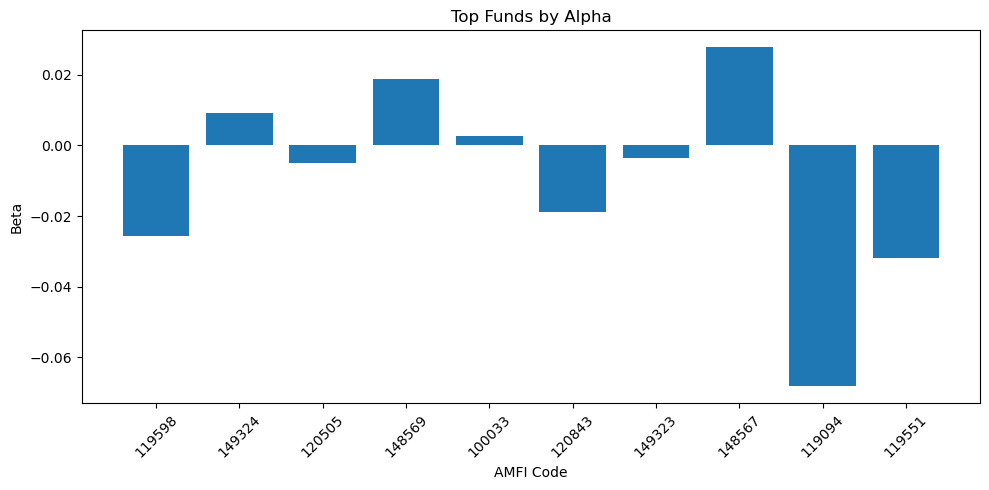

In [48]:
# Beta Chart
top10 = alpha_beta_df.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["Beta"]
)

plt.xticks(rotation=45)

plt.xlabel("AMFI Code")

plt.ylabel("Beta")

plt.title("Top Funds by Alpha")

plt.tight_layout()

plt.savefig("../reports/19_alpha_beta_analysis.png")

plt.show()

In [49]:
## Insight

# Linear regression was used to estimate Alpha and Beta for each mutual fund against the Nifty 100 benchmark. Beta measures the fund's sensitivity to market movements, while Alpha represents the annualized excess return after accounting for market risk. Funds with higher Alpha generated superior risk-adjusted performance.

In [50]:
# task-6

In [51]:
# Calculate Maximum Drawdown
results = []

for amfi_code, group in df.groupby("amfi_code"):

    group = group.copy()

    # Running maximum NAV
    group["running_max"] = group["nav"].cummax()

    # Drawdown
    group["drawdown"] = (
        group["nav"] / group["running_max"]
    ) - 1

    # Maximum drawdown row
    worst_row = group.loc[group["drawdown"].idxmin()]

    # Peak before worst drawdown
    peak_rows = group[group["date"] <= worst_row["date"]]
    peak_row = peak_rows.loc[peak_rows["nav"].idxmax()]

    results.append({
        "amfi_code": amfi_code,
        "Maximum_Drawdown": worst_row["drawdown"],
        "Peak_Date": peak_row["date"],
        "Worst_Drawdown_Date": worst_row["date"]
    })

drawdown_df = pd.DataFrame(results)

In [52]:
# Rank Funds
drawdown_df = drawdown_df.sort_values(
    by="Maximum_Drawdown"
)

print(drawdown_df.head())

    amfi_code  Maximum_Drawdown  Peak_Date Worst_Drawdown_Date
22     119599         -0.525742 2023-01-17          2025-10-28
17     119095         -0.516778 2025-05-22          2026-05-11
4      101207         -0.354469 2024-11-21          2026-05-11
39     149324         -0.311719 2024-05-03          2025-01-03
21     119598         -0.287060 2024-08-28          2025-05-14


In [53]:
# Save CSV
drawdown_df.to_csv(
    "../data/processed/maximum_drawdown_analysis.csv",
    index=False
)

print("Maximum Drawdown analysis saved successfully!")

Maximum Drawdown analysis saved successfully!


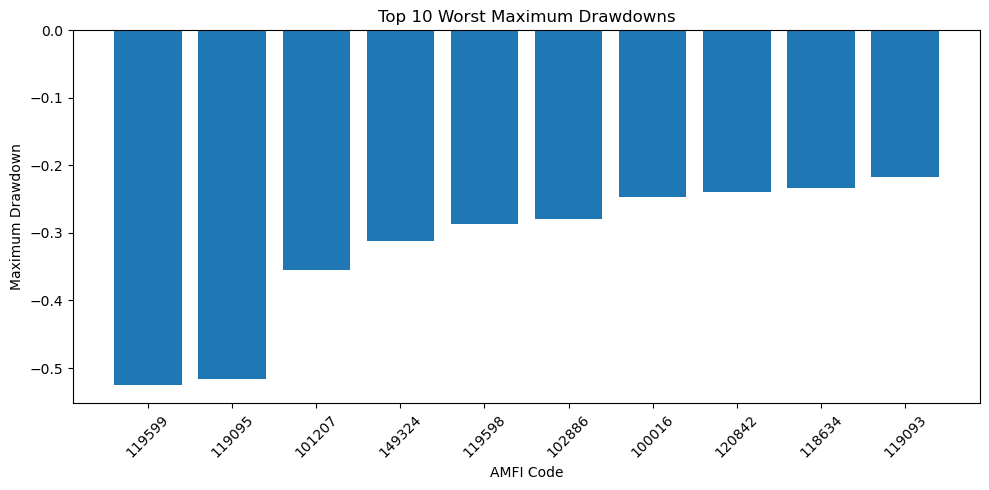

In [54]:
# Top 10 Worst Drawdowns Chart
top10 = drawdown_df.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["Maximum_Drawdown"]
)

plt.xticks(rotation=45)

plt.xlabel("AMFI Code")
plt.ylabel("Maximum Drawdown")
plt.title("Top 10 Worst Maximum Drawdowns")

plt.tight_layout()

plt.savefig("../reports/20_maximum_drawdown.png")

plt.show()

In [55]:
## Insight

# Maximum Drawdown measures the largest percentage decline from a fund's previous peak NAV. The analysis identifies the worst drawdown for each mutual fund along with the corresponding peak date and drawdown date, helping evaluate downside risk and recovery potential.

In [56]:
# task-7

In [57]:
# Load Files
cagr = pd.read_csv("../data/processed/cagr_comparison_table.csv")

sharpe = pd.read_csv("../data/processed/sharpe_ratio_ranking.csv")

alpha = pd.read_csv("../data/processed/alpha_beta.csv")

drawdown = pd.read_csv("../data/processed/maximum_drawdown_analysis.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

In [58]:
# Keep Required Columns
cagr = cagr[["amfi_code","CAGR_3Y"]]

sharpe = sharpe[["amfi_code","Sharpe_Ratio"]]

alpha = alpha[["amfi_code","Alpha"]]

drawdown = drawdown[["amfi_code","Maximum_Drawdown"]]

performance = performance[["amfi_code","expense_ratio_pct"]]

In [59]:
# Merge All Tables
score = cagr.merge(sharpe,on="amfi_code")

score = score.merge(alpha,on="amfi_code")

score = score.merge(drawdown,on="amfi_code")

score = score.merge(performance,on="amfi_code")

In [60]:
print(score.head())

   amfi_code    CAGR_3Y  Sharpe_Ratio     Alpha  Maximum_Drawdown  \
0     100016   1.292649     -0.187695  0.039779         -0.247344   
1     100025   3.916390     -0.533351  0.044157         -0.043083   
2     100033  32.442459      1.123514  0.277769         -0.162172   
3     101206  28.967695      1.025459  0.213870         -0.112916   
4     101207  -4.152381      0.197367  0.118206         -0.354469   

   expense_ratio_pct  
0               1.55  
1               0.56  
2               1.38  
3               1.60  
4               1.53  


In [61]:
# Create Ranks
## Higher value is better
score["Return_Rank"] = score["CAGR_3Y"].rank(ascending=False)

score["Sharpe_Rank"] = score["Sharpe_Ratio"].rank(ascending=False)

score["Alpha_Rank"] = score["Alpha"].rank(ascending=False)

In [62]:
## Lower Expense Ratio = Better
score["Expense_Rank"] = score["expense_ratio_pct"].rank(ascending=True)

In [63]:
## Lower Drawdown (less negative) = Better
score["Drawdown_Rank"] = score["Maximum_Drawdown"].rank(ascending=False)

In [64]:
# Convert Rank into Score
n = len(score)

score["Return_Score"] = ((n-score["Return_Rank"])/(n-1))*100

score["Sharpe_Score"] = ((n-score["Sharpe_Rank"])/(n-1))*100

score["Alpha_Score"] = ((n-score["Alpha_Rank"])/(n-1))*100

score["Expense_Score"] = ((n-score["Expense_Rank"])/(n-1))*100

score["Drawdown_Score"] = ((n-score["Drawdown_Rank"])/(n-1))*100

In [65]:
# Fund Score
score["Fund_Score"] = (

      score["Return_Score"]*0.30

    + score["Sharpe_Score"]*0.25

    + score["Alpha_Score"]*0.20

    + score["Expense_Score"]*0.15

    + score["Drawdown_Score"]*0.10

)

In [66]:
# Overall Rank
score = score.sort_values(
    by="Fund_Score",
    ascending=False
)

score["Overall_Rank"] = range(1,len(score)+1)

In [67]:
# Final Result
print(score[
[
"Overall_Rank",
"amfi_code",
"Fund_Score"
]
].head(10))

    Overall_Rank  amfi_code  Fund_Score
34             1     148567   85.384615
25             2     120505   81.794872
30             3     120843   81.025641
2              4     100033   80.769231
24             5     120504   79.487179
16             6     119094   75.512821
19             7     119551   74.166667
36             8     148569   73.012821
3              9     101206   67.371795
21            10     119598   66.538462


In [68]:
# Save CSV
score.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard saved successfully!")

Fund Scorecard saved successfully!


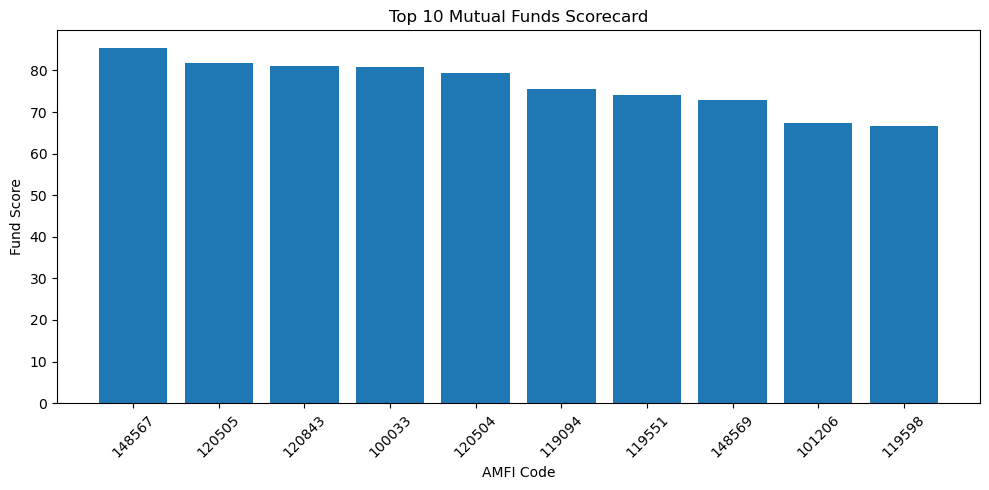

In [69]:
top10 = score.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["Fund_Score"]
)

plt.xticks(rotation=45)

plt.xlabel("AMFI Code")

plt.ylabel("Fund Score")

plt.title("Top 10 Mutual Funds Scorecard")

plt.tight_layout()

plt.savefig("../reports/21_fund_scorecard.png")

plt.show()

In [70]:
## Insight

# The composite Fund Score combines long-term returns, risk-adjusted performance, alpha generation, expense efficiency, and downside risk into a single 0–100 score. Higher scores indicate stronger overall fund performance across multiple evaluation criteria.

In [71]:
# task-8


In [72]:
# Load Datasets
fund_score = pd.read_csv("../data/processed/fund_scorecard.csv")

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [73]:
# Convert Date Columns
nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

In [74]:
# Select Top 5 Funds
top5 = fund_score.sort_values("Overall_Rank").head(5)

top5_codes = top5["amfi_code"].tolist()

print(top5_codes)

[148567, 120505, 120843, 100033, 120504]


In [75]:
# Keep Last 3 Years Data
latest_date = nav["date"].max()

start_date = latest_date - pd.DateOffset(years=3)

nav = nav[nav["date"] >= start_date]

benchmark = benchmark[benchmark["date"] >= start_date]

In [76]:
# Filter Top 5 Funds
fund_nav = nav[nav["amfi_code"].isin(top5_codes)].copy()

In [77]:
# Calculate Fund Daily Returns
fund_nav = fund_nav.sort_values(["amfi_code","date"])

fund_nav["fund_return"] = (
    fund_nav
    .groupby("amfi_code")["nav"]
    .pct_change()
)

In [78]:
# Prepare Benchmarks
benchmark = benchmark[
    benchmark["index_name"].isin(["NIFTY50","NIFTY100"])
].copy()

benchmark = benchmark.sort_values(["index_name","date"])

benchmark["benchmark_return"] = (
    benchmark
    .groupby("index_name")["close_value"]
    .pct_change()
)

In [79]:
# Normalize Values for Comparison Chart
fund_plot = fund_nav.copy()

fund_plot["Normalized_NAV"] = (
    fund_plot
    .groupby("amfi_code")["nav"]
    .transform(lambda x: x/x.iloc[0]*100)
)

benchmark["Normalized_Index"] = (
    benchmark
    .groupby("index_name")["close_value"]
    .transform(lambda x: x/x.iloc[0]*100)
)

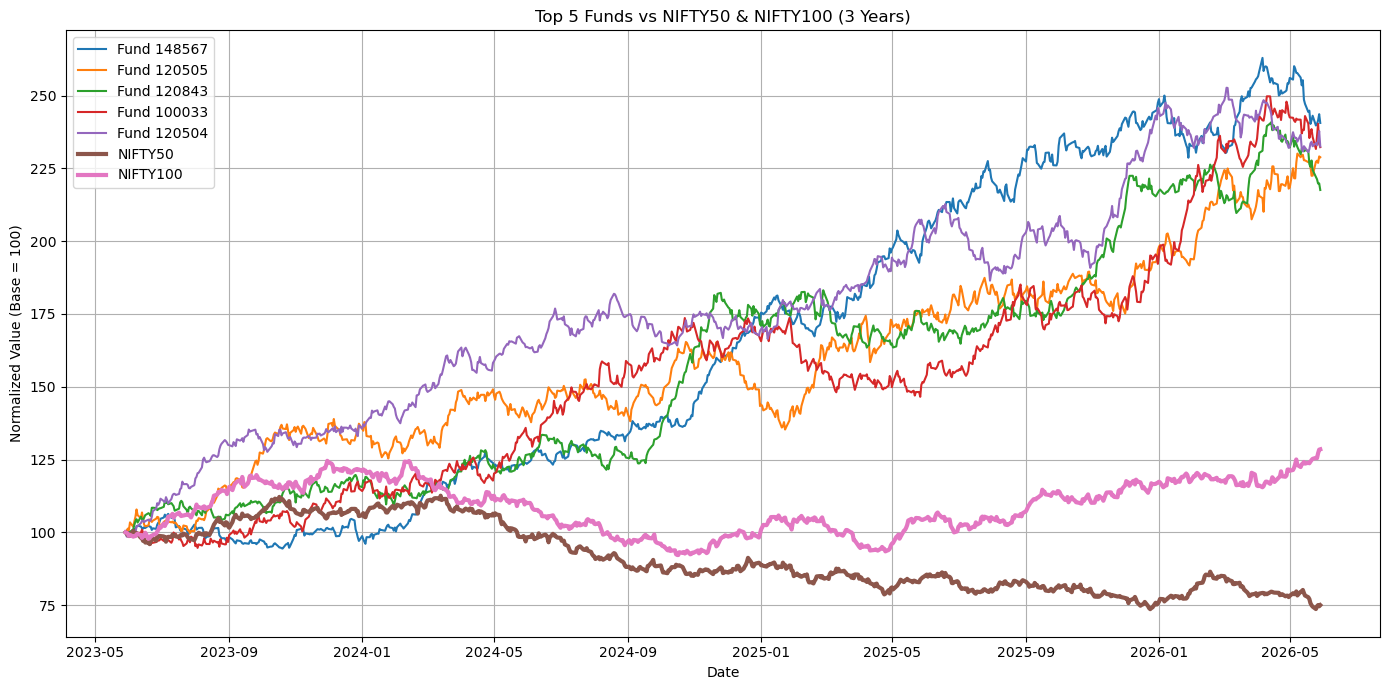

In [80]:
# Plot Comparison
plt.figure(figsize=(14, 7))

# Plot Top 5 Funds
for code in top5_codes:
    temp = fund_plot[fund_plot["amfi_code"] == code]

    plt.plot(
        temp["date"],
        temp["Normalized_NAV"],
        label=f"Fund {code}"
    )

# Plot Benchmarks
for idx in ["NIFTY50", "NIFTY100"]:

    temp = benchmark[benchmark["index_name"] == idx]

    plt.plot(
        temp["date"],
        temp["Normalized_Index"],
        linewidth=3,
        label=idx
    )

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100 (3 Years)")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("../reports/22_benchmark_comparison.png")

plt.show()


In [81]:
# Tracking Error
tracking_results = []

for code in top5_codes:

    fund = fund_nav[
        ["date","amfi_code","fund_return"]
    ]

    fund = fund[fund["amfi_code"]==code]

    for benchmark_name in ["NIFTY50","NIFTY100"]:

        bm = benchmark[
            benchmark["index_name"]==benchmark_name
        ][["date","benchmark_return"]]

        merged = pd.merge(
            fund,
            bm,
            on="date",
            how="inner"
        )

        merged = merged.dropna()

        tracking_error = (
            (
                merged["fund_return"]
                -
                merged["benchmark_return"]
            ).std()
        ) * np.sqrt(252)

        tracking_results.append({
            "amfi_code":code,
            "Benchmark":benchmark_name,
            "Tracking_Error":tracking_error
        })

tracking_df = pd.DataFrame(tracking_results)

print(tracking_df)

   amfi_code Benchmark  Tracking_Error
0     148567   NIFTY50        0.191868
1     148567  NIFTY100        0.187974
2     120505   NIFTY50        0.228447
3     120505  NIFTY100        0.232661
4     120843   NIFTY50        0.205067
5     120843  NIFTY100        0.206540
6     100033   NIFTY50        0.228222
7     100033  NIFTY100        0.224976
8     120504   NIFTY50        0.188211
9     120504  NIFTY100        0.187299


In [82]:
# Save CSV
tracking_df.to_csv(
    "../data/processed/tracking_error_analysis.csv",
    index=False
)

print("Tracking Error saved successfully!")

Tracking Error saved successfully!


In [83]:
## Insight

# The benchmark comparison chart shows how the top five mutual funds performed against the NIFTY50 and NIFTY100 indices over the last three years. Tracking Error measures how closely each fund follows its benchmark; a lower tracking error indicates performance more closely aligned with the benchmark, while a higher value reflects greater deviation.